In [1]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np
from tqdm import tqdm
import time
from numba import njit, prange

# 1. Spatial Impulse Response (SIR) of far-field rectangular apertures : The Tupholme - Stephanishen approach.

Placing the rectangular aperture $ m $ of width and height $ w_{mx}, w_{my} $ in the $ x\text{-}y $ plane with its center at the coordinate $ \vec{r}_m $, the field point position vector—from the \( m \)-th rectangle to the \( p \)-th field point—is

$$
\vec{r}_{(m,p)} = \vec{r}_p - \vec{r}_m
$$

where $ \vec{r}_p $ are the coordinates of the field point. This vector can be further decomposed into a distance

$$
l_{(m,p)} = \| \vec{r}_{(m,p)} \|
$$

and a unit vector

$$
\vec{u}_{(m,p)} = \frac{\vec{r}_{(m,p)}}{\| \vec{r}_{(m,p)} \|} = (x_u, y_u, z_u)
$$

Using this description, one can get the following equations:

$$
\begin{align*}
t_1 &= \frac{l_{(m,p)}}{c_0} - \frac{\Delta t_1 + \Delta t_2}{2} \\
t_2 &= t_1 + \Delta t_1 \\
t_3 &= t_1 + \Delta t_2 \\
t_4 &= t_1 + \Delta t_1 + \Delta t_2 \tag{13}
\end{align*}
$$

Where $ \Delta t_1 $ and $ \Delta t_2 $ correspond to the minimum and maximum time-of-flight (TOF) for the side lengths of the rectangle:

$$
\Delta t_1 = \min\left(\frac{w_{my} y_u}{c_0}, \frac{w_{mx} x_u}{c_0}\right) \tag{14}
$$

$$
\Delta t_2 = \max\left(\frac{w_{my} y_u}{c_0}, \frac{w_{mx} x_u}{c_0}\right) \tag{15}
$$

Note that $ t_2 - t_1 = t_4 - t_3 = \Delta t_1 $ and $ t_3 - t_2 = \Delta t_2 - \Delta t_1 $, and that there are some cases where some of the $ t $'s are identical and thus have $ \Delta t_1 $ and/or $ \Delta t_2 $ equal to zero.

The shape of the trapezoid is a function of $ \Delta t_1 $ and $ \Delta t_2 $ and so is its amplitude, but the area of the trapezoid integrated over the whole time interval is always equal to:

$$
a_{rec}(l) = \frac{w_{mx} w_{my}}{2\pi l_{(m,p)}} \tag{16}
$$

Geometrically, the area can also be expressed as

$$
a_{rec} = h_{max} \Delta t_2 \tag{17}
$$

Combining (16) and (17) gives the trapezoid amplitude:

$$
h_{(m,p)}^{plateau} = \frac{w_{mx} w_{my}}{2\pi \Delta t_2 l_{(m,p)}} \tag{18}
$$

Then, the far-field trapezoidal SIR for an $ m $-th rectangular aperture is described by

$$
h_m(\vec{r}_p, t) = h(\vec{u}_{(m,p)}, l_{(m,p)}, w_{mx}, w_{my}, t) =
\begin{cases}
s_{(m,p)} (t - t_1), & t_1 < t < t_2 \\
h_{(m,p)}^{plateau}, & t_2 < t < t_3 \\
s_{(m,p)} (t_4 - t), & t_3 < t < t_4 \\
0, & \text{elsewhere}
\end{cases}
\tag{19}
$$

with

$$
s_{(m,p)} = \frac{h_{(m,p)}^{plateau}}{\Delta t_1} \tag{20}
$$

So, with the informations of the 5 parameteres we can compute all SIR of each small rectangle that composes the transducer. 
Now we are going to create a function to visualize the contribution of each small subdivision.


# 2. Methods for computation of transducer SIR

The last trapezoidal SIR for each small rectangle is valid just if the subdivisions that are in far-field condition, then they must meet the next condition

$$
w \ll \sqrt{\frac{4 l c_0 }{f}} \tag{21}
$$

Where $l$ is the distance to the field point, $w$ the largest dimension of the rectangle and $f$ is the highest frequency in the response simulated. 

Thus, if this condition is guaranteed, thanks to the linearity assumption, we can obtain the next expression for the Transducer SIR shape.

$$
h_{tx}(\vec{r}_p, t) \approx \sum_{m=1}^{M} a_m \, h_m(\vec{r}_p, t - \tau_m) \tag{22}
$$

Where $h_m$ corresponds to the SIR showed in eq.[19], and $a_m, \tau_m$ corresponds to the apodization and delay applied to that specific patch. 
Therefore, to compute the transducer SIR, we need to add up each small patch $m$ SIR, of the $M$ patches making up the transducer.

## 2.1. Visualization of the methods.

In this 2nd section, we describe the Naive and the Sparse Delta Integration (SDI) methods.

The naive method loops over the range of time where the trapezoidal piecewise function is defined, from $t_1$ to $t_4$, filling all non-zero trapezoid values per patch. In contrast, the proposed SDI method rewrites the trapezoid shape as the double integration of Dirac delta distributions—the complete development will be explained in the next subsection. This mathematical trick allows us, instead of looping over all time samples within $[t_1, t_4]$ for each patch, to compute only 8 sample points (for discrete implementation, 8 deltas are needed instead of 4) for all patches, at the expense of a double integration on time after looping all patches. To give a glimpse of the methods, the next GUI has as its objective to let you play with a simple trapezoid and the parameters that define it.

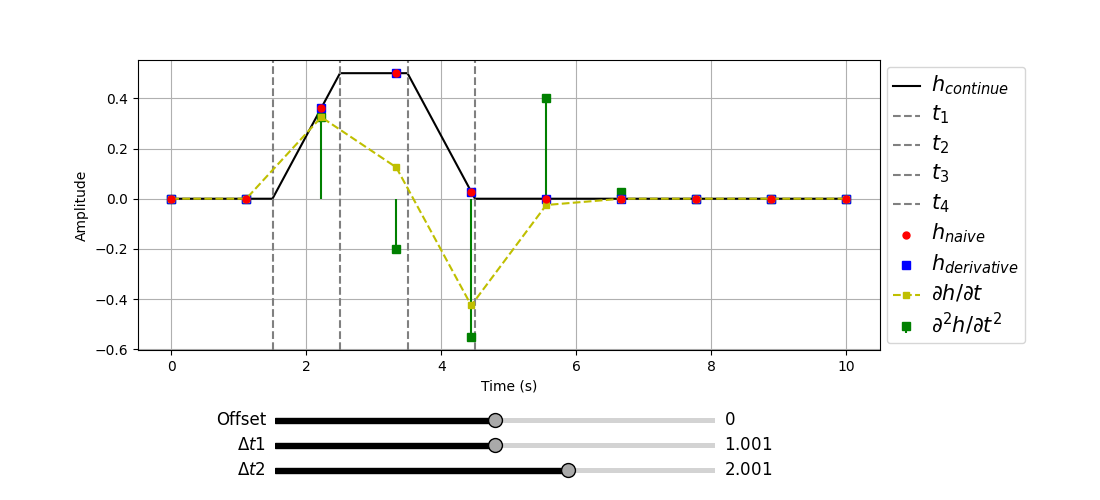

In [3]:
%matplotlib widget
from trapezoid_method_visualization import plot_trapezoid_methods

area = 1
l_c = 3

# Initial parameters and its range
Dt1 = 1
Dt2 = 2
shift = 0
range_Dt1 = (0.001, 2)
range_Dt2 = (0.001, 3)
range_shift = (-1, 1)

plot_trapezoid_methods(
    area, l_c, Dt1, Dt2, shift, range_Dt1, range_Dt2, range_shift
)

In [4]:
plt.close()
%matplotlib inline

## 2.2. Patches' SIR visualization

From the development showed in section 1, we can start to define the function we'll need to compute the trapezoids.

In [5]:
inv_2pi = 1/(2*np.pi)

# ---------- small helper (njit) for rectangle SIR parameters ----------
@njit
def compute_rectangle_SIR_params(wx, wy, dx, dy, dist, inv_c, apod, delay, dt):
    """
    Return t1,t2,t3,t4,h_max (float32).
    dx,dy are direction cosines (xp, yp) used in your original compute.
    dist is distance from patch center to field point (float).
    inv_c is 1/c (float).
    """
    xp_abs = abs(dx) * wx * inv_c
    yp_abs = abs(dy) * wy * inv_c
    # enforce minimum to avoid zero width
    Dt1 = min(xp_abs, yp_abs)
    Dt2 = max(xp_abs, yp_abs)
    if Dt1 < dt:
        Dt1 = dt
    if Dt2 < dt:
        Dt2 = dt

    area = (wx * wy * inv_2pi) / dist
    # time-of-flight base
    t1 =  dist * inv_c - 0.5 * (Dt1 + Dt2) + delay
    t2 = t1 + Dt1
    t3 = t1 + Dt2
    t4 = t1 + Dt1 + Dt2
    h_max = area / Dt2 * apod

    return t1, t2, t3, t4, h_max


To see how this would like for a certain transducer geometry, let create a function that will compute al these events in function of field point and patches of the transducer as follows

In [6]:
@njit(parallel=True)
def compute_all_events(P, M, pts, centers, wx, wy, c, apods, delays, events, dt):
    for p in prange(P):
        for i in range(M):
            dx = pts[p, 0] - centers[i, 0]
            dy = pts[p, 1] - centers[i, 1]
            dz = pts[p, 2] - centers[i, 2]
            dist = np.sqrt(dx * dx + dy * dy + dz * dz)

            xp, yp = dx / (dist), dy / (dist)
            t1, t2, t3, t4, h_max = compute_rectangle_SIR_params(
                wx,
                wy,
                xp,
                yp,
                dist,
                1/c,
                apods[i],
                delays[i],
                dt,
            )
            events[p, i, 0] = t1
            events[p, i, 1] = t2
            events[p, i, 2] = t3
            events[p, i, 3] = t4
            events[p, i, 4] = h_max

To create the transducer, we are going to use some predefined functions from the package. If you are looking for more information on how to use and define transducer objects, please refer to the Tutorial_PyField.

Let's create a linear array with 128 elements and no subdivision to make it easier. Note that if no subdivision is done, the far-field condition of the trapezoidal spatial impulse response (SIR) may not be met, and therefore our pressure field is not well simulated. However, we'll continue like this just for pedagogic purposes.

LinearArrayTransducer initialized in 0.0010 seconds.


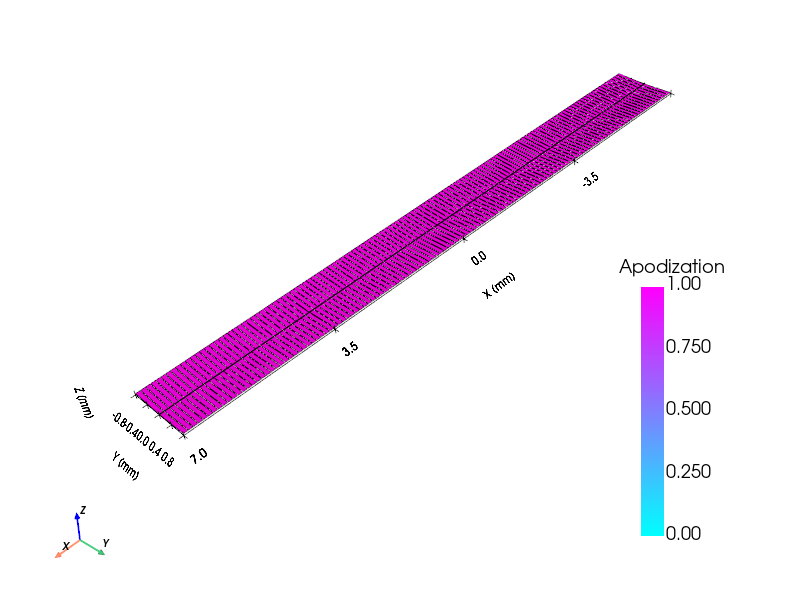

In [7]:
import pysonogen.transducers as transducers

# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
tx_freq = 12.5  # MHz
elevation_focus_mm = 8  # mm
sub_x = 1
sub_y = 2

MyTransducer = transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = sub_x,
    no_sub_y           = sub_y,
    frequency_Hz       = tx_freq*1e6,  # MHz),
    )

MyTransducer.show(notebook = True, jupyter_backend='static')

From this object we are going to take the variable to input in our function that computes all the events (patches - field point combinations):

In [8]:
# SIR Parameters

f_sampling = 200e6  # Hz
dt = 1 / f_sampling  # s
field_point_mm = np.array([[3, 0, 8]])  # mm
c = 1540  # speed of sound (m/s)

# Transducer geometry parameters
# Lets compute the patch parameters
centers, apods, delays = [], [], []
for elem in range(MyTransducer.n_elements):
    for sub_elem in range(MyTransducer.no_sub_x * MyTransducer.no_sub_y):
        verts = MyTransducer.sub_quad_verts[
            elem * (MyTransducer.no_sub_x * MyTransducer.no_sub_y) + sub_elem
        ]
        centers.append(verts.mean(axis=0))
        apods.append(MyTransducer.apodization[elem])
        delays.append(MyTransducer.delays[elem])

centers = np.array(centers, dtype=np.float32)  # shape (M, 3)
apods = np.array(apods, dtype=np.float32)  # shape (M,)
delays = np.array(delays, dtype=np.float32)  # shape (M,)
wx = MyTransducer.elem_width  # element width (m)
wy = MyTransducer.elem_height  # element height (m)

# Let's compute the events for a single field point and all patches of the transducer
P = field_point_mm.shape[0]  # number of field points
M = centers.shape[0]  # number of patches

pts = field_point_mm * 1e-3  # (P,3) array of field points (m)
events = np.zeros((P, M, 5), dtype=np.float32)  # (P,M,5) array of events
print("events shape:", events.shape)

events shape: (1, 256, 5)


In [9]:
compute_all_events(P, M, pts, centers, wx, wy, c, apods, delays, events, dt)

And let's create a function to visualize how each event look like

In [10]:
def plot_SIR_events(events, y_subdiv, *, ax = None, cmap = None):
    # Plot the contribution of each element to the field point

    # Add a colorbar
    n_elements = events.shape[1] // y_subdiv  # Correct calculation
    if cmap is None:
        cmap = plt.get_cmap('jet')
    else:
        cmap = plt.get_cmap(cmap)

    colors = cmap(np.linspace(0, 1, n_elements))
        
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n_elements))
    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(14, 4))


    for i in range(n_elements):
        for j in range(y_subdiv): # loop over subdivisions in elevation
            m = j + i*y_subdiv
            t1, t2, t3, t4, h_max = events[0, m,:]
            ax.plot([t1*1e6, t2*1e6], [0, h_max], color=colors[i], lw=2, linestyle='solid')
            ax.plot([t2*1e6, t3*1e6], [h_max, h_max], color=colors[i], lw=2, linestyle='solid')
            ax.plot([t3*1e6, t4*1e6], [h_max, 0], color=colors[i], lw=2, linestyle='solid')
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('SIR (a.u.)')
    # ax.set_yscale('log')
    ax.set_title(f'Contribution of each element to the field point at {field_point_mm[0]} mm')
    ax.grid()
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Element Index')


    if flag_return_ax:
        return ax

LinearArrayTransducer initialized in 0.0015 seconds.


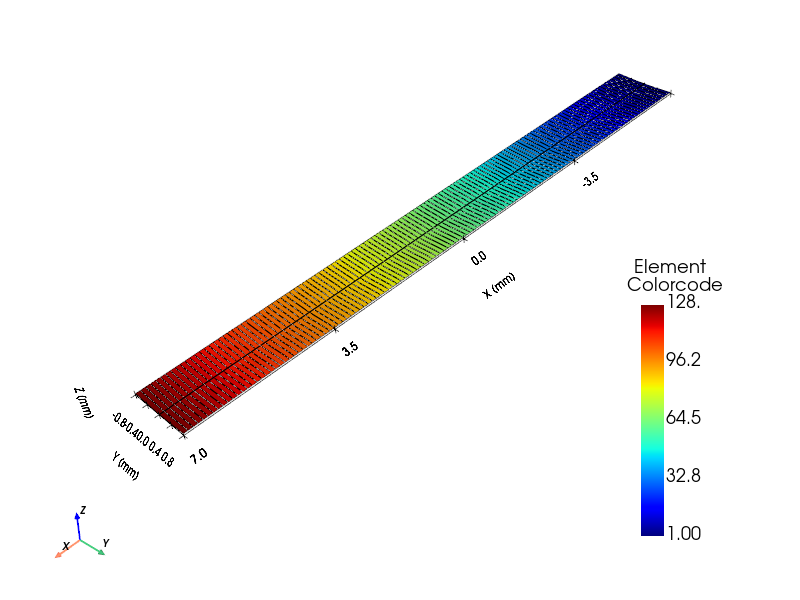

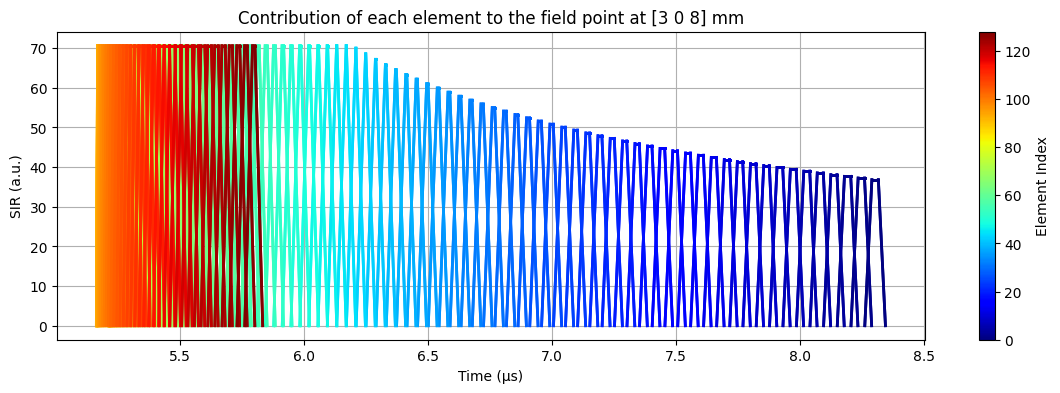

In [11]:
cmap = 'jet'

colormap = plt.get_cmap(cmap)

elem_colors = colormap(np.linspace(0, 1, n_elements))

# Let's use the delays to visualize the colorcode of each element
# Create a helper transducer to visualize the delays as element colormap
# without redefining MyTransducer instance.
Help_transducer = transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = sub_x,
    no_sub_y           = sub_y,
    frequency_Hz       = tx_freq*1e6,  # MHz),
    )

Help_transducer.set_delays(np.linspace(1, n_elements, n_elements))
Help_transducer.show(notebook = True, jupyter_backend='static', scalars = 'Delays', cmap=cmap, colorbar_title = 'Element \n Colorcode')

plot_SIR_events(events, sub_y, cmap = cmap)


## 2.2. Naive method

The naive approach is the direct one, where one would loop over the timegrid vector to add for each point and patch the contributions. So the function would look as something like this.

In [12]:
# for a point p, element m, we have event = (t1, t2, t3, t4, h_max)
# we want to compute h_out[p, k] += h(t) where t = time_grid[k]
# and h(t) is the trapezoid defined by event
# k_start and k_end define the range of time samples to consider for this event

@njit
def naive_method(t1, t2, t3, t4, h_max, time_grid, h_out, p, k_start, k_end):
    slope = h_max / (t2 - t1)  # slope of rising and falling edges    

    # loop over every sample that might see part of this trapezoid
    for k in range(k_start, k_end):
        t = time_grid[k]
        # evaluate continuous trapezoid h(t)
        if t < t1 or t > t4:
            continue
        elif t < t2:
            h = slope * (t - t1) 
        elif t < t3:
            h = h_max
        else:
            h = slope * (t4 - t)

        # accumulate
        h_out[p, k] += h

## 2.3. Sparse Delta Integration (SDI)

From the derivation on equation [19], we can see that the first derivative of the trapezoid piecewise function can be written as follows:

$$
\frac{\partial h_m(\vec{r}_p, t)}{\partial t} =
\begin{cases}
s_{(m,p)}, & t_1 < t < t_2 \\
-s_{(m,p)}, & t_3 < t < t_4 \\
0, & \text{elsewhere}
\end{cases}
= s_{(m,p)} \cdot \left[ u(t-t_1) - u(t-t_2) - u(t-t_3) + u(t-t_4) \right]
\tag{24}
$$

Where $s_{(m,p)}$ is a function of the $m$-patch geometry and the field point $p$ as depicted in equation 20, and $u(t)$ is the Heaviside step function, defined as

$$
u(t) =
\begin{cases}
1, & t \geq 0 \\
0, & t < 0
\end{cases}
$$

If we continue with further derivation, we get the next expression:

$$
\frac{\partial^2 h_m(\vec{r}_p, t)}{\partial t^2} = s_{(m,p)} \cdot \left[ \delta(t-t_1) - \delta(t-t_2) - \delta(t-t_3) + \delta(t-t_4) \right] = s_{(m,p)} \Delta\delta(t)
\tag{25}
$$

Where $\delta(t)$ stands for the unit impulse or Dirac delta distribution, defined as

$$
\delta(t) =
\begin{cases}
1, & t = 0 \\
0, & t \neq 0
\end{cases}
$$
And

$$
\Delta\delta(t) = \delta(t-t_1) - \delta(t-t_2) - \delta(t-t_3) + \delta(t-t_4)
\tag{30}
$$

Thus, we can rewrite the piecewise function shown in [19] as

$$
h_{e,m}(\vec{r}_p, t) = \int_{-\infty}^{t}  \int_{-\infty}^{t'} s_{(m,p)} \Delta\delta(t'') \, dt''  dt'
\tag{26}
$$

Thanks to the additive property of the integrals, the SIR for a transducer composed of $M$ patches becomes

$$
h_{tx}(\vec{r}_p, t) \approx \sum_{m_e}^{M} a_e h_{e,m}(\vec{r}_p, t - \tau_e) = \int_{-\infty}^{t}  \int_{-\infty}^{t'} \left[\sum_{m_e}^{M}  a_e s_{(m,p)} \Delta\delta(t''  - \tau_e) \right] dt''  dt'
\tag{27}
$$


For implementation, the temporal axis must be discretized, which requires careful handling of the delta function contributions. The continuous variable $t$ is replaced by its sampled version $\{ t_k \}$, a vector of $T$ samples as defined in Eq. [24]. Unlike the piecewise trapezoidal function defined by the four times $(t_1, t_2, t_3, t_4)$, the reformulated method uses delta functions located exactly at these times. Since $t_1, \ldots, t_4$ do not necessarily coincide with the discrete grid $\{ t_k \}$, their contributions must be distributed to the closest discrete samples.

Intuitively, this means that instead of placing a delta “between samples” (which would be lost on the grid), we split its weight between the two nearest time samples. This ensures that the total contribution is preserved while being consistent with the discrete representation. Formally, given a continuous time $t' \in \mathbb{R}$, its index position in the sampled grid is

$$
k_{t'} = \frac{t' - t_0}{dt}
\tag{28}
$$

Here $k_{t'} \in \mathbb{R}$, while $k \in \mathbb{Z}^+$ represents valid discrete indices. Thus, instead of assigning the delta exactly at $t'$, its amplitude is distributed between the two nearest discrete grid points, using linear weights:

$$
w^f(t') = k_{t'} - \lfloor k_{t'} \rfloor, \qquad w^c(t') = \lceil k_{t'} \rceil - k_{t'} = w^f(t') + 1
\tag{29}
$$

Where now $\lfloor k_{t'} \rfloor \in \mathbb{Z}^+$ and $\lceil k_{t'} \rceil \in \mathbb{Z}^+$, and correspond to the floor and ceil value of the number $k_{t'}$ that can now be used as index. Then, for taking the lower and higher value between $\{ t_k \}$ closest to $t'$, we define

$$
t^f = t_{\lfloor k_t \rfloor}, \qquad t^c = t_{\lceil k_t \rceil}
\tag{30}
$$

Where $t_{\lfloor k_{t'} \rfloor}$ means that we are evaluating our time vector at the index $\lfloor k_{t'} \rfloor$, and the same for $\lceil k_t \rceil$. With this interpolation, the discrete version of the deltas defined in equation [29] becomes

$$
\Delta\delta(t_k) = \Delta\delta(t_k)^{\text{ceil}} + \Delta\delta(t_k)^{\text{floor}}
\tag{31}
$$

With

$$
\Delta\delta(t_k)^{\text{floor}} = w^f(t_1) \delta(t_k - t_1^f) - w^f(t_2) \delta(t_k - t_2^f) - w^f(t_3) \delta(t_k - t_3^f) + w^f(t_4) \delta(t_k - t_4^f)
\tag{32}
$$

$$
\Delta\delta(t_k)^{\text{ceil}} = w^c(t_1) \delta(t_k - t_1^c) - w^c(t_2) \delta(t_k - t_2^c) - w^c(t_3) \delta(t_k - t_3^c) + w^c(t_4) \delta(t_k - t_4^c)
\tag{33}
$$

This weighting ensures that the delta contributions are properly mapped onto the discrete time grid, by adding four more deltas.

In [13]:
# Precompute signs array for SDI method
signs = np.array((1.0,-1.0,-1.0,1.0), dtype=np.float32)

@njit
def sdi_method(t1, t2, t3, t4, h_max, d2h_out, t0, fs, T, p) :

    slope = h_max / (t2 - t1)  # slope of rising and falling edges    
    tis = np.array((t1,t2,t3,t4), dtype=np.float32)

    for idx in range(4):
        #Find real not integer sample index
        k_t = (tis[idx] - t0) * fs

        # Find the two nearest samples and their weights
        k_floor = int(np.floor(k_t))
        # Clamp k_floor to valid range
        # k_floor = max(0, min(k_floor, T-2))
        k_ceil = k_floor + 1

        if k_t < 0 or k_t > T-1:
            print("Warning: event outside time grid in point ", p)
            continue
        else:
            w_ceil = k_t - k_floor
            w_floor = 1 - w_ceil

            # Assign the weights to the two nearest samples
            d2h_out[p, k_floor] += signs[idx] * slope * w_floor
            d2h_out[p, k_ceil] += signs[idx] * slope * w_ceil

    return d2h_out


## 2.4. Accumulation of patches' SIR

We now create a function that will compute the SIR taking advantage of the parallel computing on the CPU.

In [14]:
@njit(parallel=True, fastmath=True)
def compute_parallelized_sir(P, M, T, events, time_grid, fs, *, method = None):
    
    if method == "sdi":
        method_flag = 1
    else:
        method_flag = 0

    dt = 1.0 / fs
    t0 = time_grid[0]
    h_sir = np.zeros((P, T), dtype=np.float32)
    d2h_sdi = np.zeros((P, T), dtype=np.float32)
    range_k_matrix = np.zeros((P, M), dtype=np.int32)

    for p in prange(P):
        for i in prange(M):
            t1, t2, t3, t4, h_max = events[p, i,:]
            if h_max < 1e-6:
                continue
            
            # Compute slope and k_start, k_end to fill the trapezoid
            k_start = int(np.floor((t1 - t0) * fs))
            k_end = int(np.ceil((t4 - t0) * fs) + 1)

            # clamp to valid range
            if k_start < 0:
                k_start = 0
            if k_end > T-1:
                k_end = T-1

            range_k = k_end - k_start
            range_k_matrix[p , i] = range_k

            # Choose method based on range_k
            if method_flag == 0:  # naive
                naive_method(t1, t2, t3, t4, h_max, time_grid, h_sir, p, k_start, k_end)
            elif method_flag == 1:  # sdi
                sdi_method(t1, t2, t3, t4, h_max, d2h_sdi, t0, fs, T, p)
            else:  
                raise ValueError("method_flag must be 0 (naive) or 1 (sdi)")
    
        # After all patches for point p processed, if any SDI events were added, integrate
        # We must integrate d2h -> dh -> h and add to h_out
        # (Even if some patches used naive, we still need to add integrated d2h)
        # First cumulative sum (in-place on a temp)

        if method_flag != 0:  # if not purely naive
            acc = 0.0
            for k in range(T):
                acc += d2h_sdi[p, k]
                d2h_sdi[p, k] = acc
                # We dont multiply by dt because delta is a point.
            acc2 = 0.0
            for k in range(T):
                acc2 += d2h_sdi[p, k]
                # multiply by dt once to match continuous integral scaling
                h_sir[p, k] += acc2 * dt

    return h_sir, range_k_matrix

Now that we have created this function to accumulate the results of both methods let's use it.

In [15]:
# You need to have run the previous cells to define the parameters

all_times = events[:, :, 0:4]
t0, tN = all_times.min(), all_times.max()

# Define time grid
min_time_samples = int(np.ceil((tN - t0) * f_sampling))
# next power of two
T = 2 ** max(int(np.ceil(np.log2(min_time_samples))), 5) # compute the next power of two, minimum 32 time samples
time_grid = t0 + np.arange(0, T) * dt  # start a bit before the first

print(f"Time samples: {T}, from {t0*1e6:.2f} us to {time_grid[-1]*1e6:.2f} us, dt = {dt*1e6:.2f} us")

Time samples: 1024, from 5.16 us to 10.28 us, dt = 0.01 us


In [39]:

# Compute the acumulated SIR using naive method
start_time = time.time()
h_naive, range_k_matrix = compute_parallelized_sir(P, M, T, events, time_grid, f_sampling, method="naive")
end_naive = time.time() 
print(f"Naive method took {end_naive-start_time:.4f} seconds")
h_sdi, _ = compute_parallelized_sir(P, M, T, events, time_grid, f_sampling, method="sdi")
end_sdi = time.time() 
print(f"SDI method took {end_sdi - end_naive:.4f} seconds")

print(h_naive.shape, h_sdi.shape)

Naive method took 0.0010 seconds
SDI method took 0.0000 seconds
(1, 1024) (1, 1024)


In [40]:
def plot_SIR_tx(time_grid, h_sir, *, ax = None, **kwargs):
    # Plot the contribution of each element to the field point

    flag_return_ax = True
    if ax is None:
        flag_return_ax = False
        fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(time_grid*1e6, h_sir[0], lw=2, **kwargs)

    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('SIR (a.u.)')
    # ax.set_yscale('log')
    ax.set_title(f'Accumulation of patchs SIR in the field point {field_point_mm[0]} mm')
    ax.grid('minor')

    if flag_return_ax:
        return ax

<Axes: title={'center': 'Accumulation of patchs SIR in the field point [-0.25 -0.5   7.  ] mm'}, xlabel='Time (µs)', ylabel='SIR (a.u.)'>

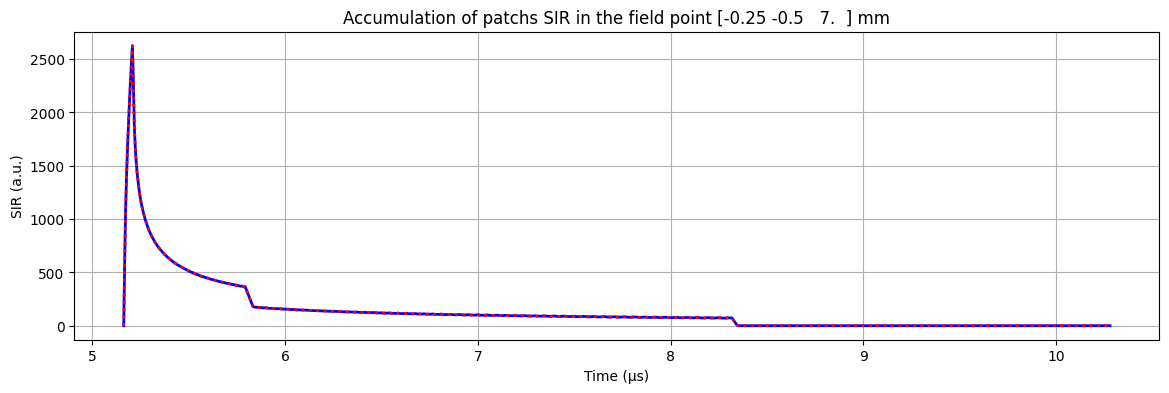

In [41]:

fig, ax = plt.subplots(figsize=(14, 4))
ax= plot_SIR_tx(time_grid, h_naive, ax = ax, color = 'blue', label = 'Naive', linestyle = 'solid')
plot_SIR_tx(time_grid, h_naive, ax = ax, color = 'red', label = 'SDI', linestyle = 'dotted')

## 2.5. Theoretical performance

In [19]:
def make_analysis_method(T, M, P, range_k_matrix):
    
    # When calling the Naive method, the range_k and T_M attributes are computed
    # and can be accessed after the first call to the object.
    kmean = np.mean(range_k_matrix)
    print(f"Mean of range_k : {kmean:.2f} for with P : {P}, T : {T}, M : {M}")
    condition_complete = 8 + 2*T/M
    print(f"Condition for complete trapezoids: {condition_complete:.2f}")

    fig, ax = plt.subplots(1,2,figsize=(10, 4))

    im = ax[0].imshow(range_k_matrix, aspect='auto', cmap = 'inferno')
    ax[0].set_title(r'a) $\Delta k$ ', fontsize=16)
    ax[0].set_xlabel('Patch index')
    ax[0].set_ylabel('Point index')
    fig.colorbar(im, ax=ax[0])

    # plot Histogram of the krange

    ax[1].hist(range_k_matrix.flatten(), bins=10, color="#E91414", edgecolor="white", alpha=0.85)
    ax[1].set_xlabel(r'$\Delta k$ values', fontsize=10)
    ax[1].set_ylabel('Events', fontsize=10)
    ax[1].set_title(r'b) Distribution of $\Delta k$', fontsize=16)
    ax[1].grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()

    return fig

Mean of range_k : 15.83 for with P : 1, T : 1024, M : 256
Condition for complete trapezoids: 16.00


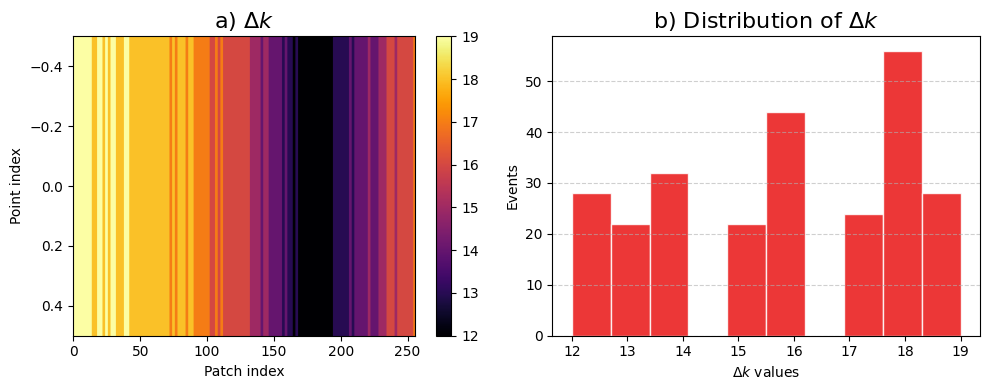

In [20]:
fig = make_analysis_method(T, M, P, range_k_matrix)

# 3. PyField

Similar functions as the ones presented in this notebook are used 

## 2.2. Creation of transducer object

In [21]:
import pysonogen
from pysonogen.transducers import Domino, Zeus_Matrix
from PyField import PyField

focus_mm = np.array([0, 0, 8])
FoverD = 1

In [22]:
x_half_size_mm = 0.25
y_half_size_mm = 0.5
z_half_size_mm = 1
x_extent_mm = [-x_half_size_mm+focus_mm[0], x_half_size_mm+focus_mm[0]]
y_extent_mm = [-y_half_size_mm+focus_mm[1], y_half_size_mm+focus_mm[1]]
z_extent_mm = [-z_half_size_mm +focus_mm[2], z_half_size_mm+focus_mm[2]]
dx_mm = 0.01
dy_mm = 0.02
dz_mm = 0.04

x = np.linspace(x_extent_mm[0], x_extent_mm[1], int((x_extent_mm[1]-x_extent_mm[0])/dx_mm)+1)
y = np.linspace(y_extent_mm[0], y_extent_mm[1], int((y_extent_mm[1]-y_extent_mm[0])/dy_mm)+1)
z = np.linspace(z_extent_mm[0], z_extent_mm[1], int((z_extent_mm[1]-z_extent_mm[0])/dz_mm)+1)
field_point_mm = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)
print(f"Number of field points: {field_point_mm.shape[0]}, and x.shape: {x.shape}, y.shape: {y.shape}, z.shape: {z.shape}")
print(f"Field points from {field_point_mm.min(axis=0)} mm to {field_point_mm.max(axis=0)} mm")

Number of field points: 132651, and x.shape: (51,), y.shape: (51,), z.shape: (51,)
Field points from [-0.25 -0.5   7.  ] mm to [0.25 0.5  9.  ] mm


### 2.2.1. Linear array probe

LinearArrayTransducer initialized in 0.0108 seconds.


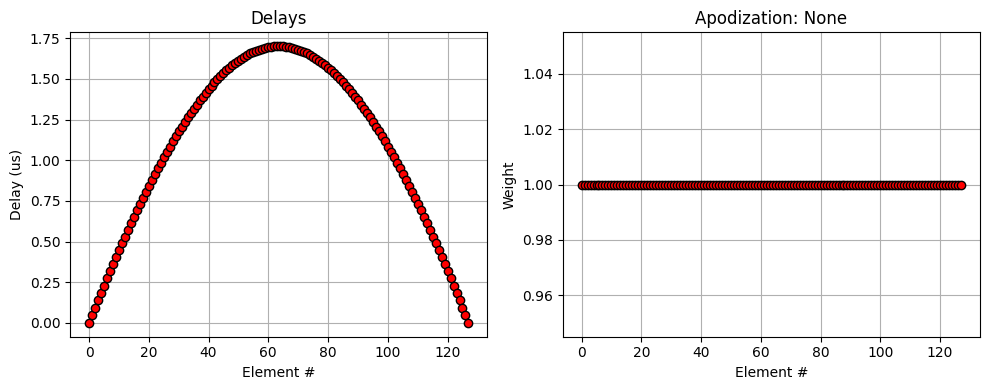

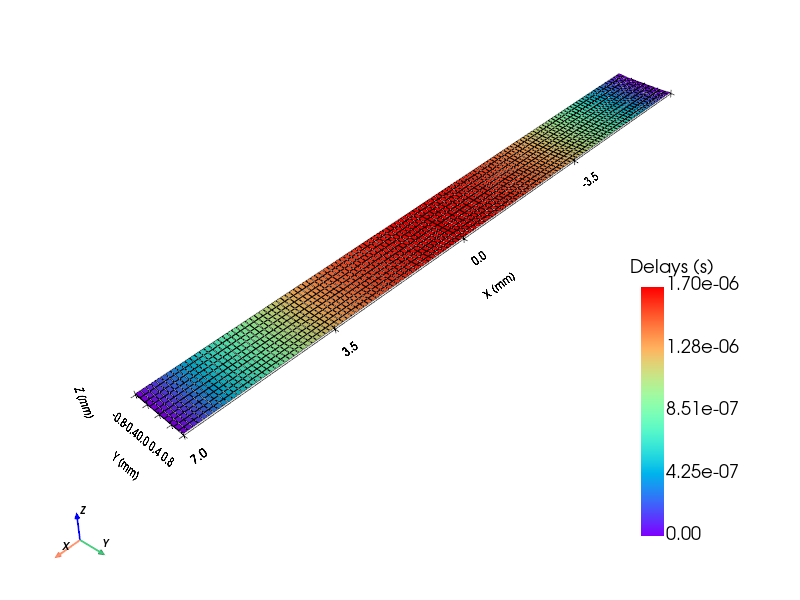

In [23]:
linear_array_probe = Domino()

delays = linear_array_probe.compute_delays(focus_mm=focus_mm)
# apodization = linear_array_probe.compute_apodization( 
#     focus_mm=focus_mm, FoverD=1)
linear_array_probe.plot_delays_apodization()
linear_array_probe.show(notebook=True, jupyter_backend='static', scalars = 'Delays')



In [25]:
linear_field = PyField(linear_array_probe)
x1, y1, z1, p_field1 = linear_field(field_point_mm, method = 'naive')

Points checked and spatial grid created in 0.01 seconds...
Computing SIR for 132651 points and 1280 patches...
Computed time grid from 4.44 us to 9.31 us, with 973 samples in 0.04 seconds.
SIR computed in 4.82 seconds...
Pressure computed from SIR in 0.74 seconds...
Pressure field computed in 7.44 seconds...


In [26]:
x1, y1, z1, p_field1 = linear_field(field_point_mm, method = 'naive')

Points checked and spatial grid created in 0.01 seconds...
Computing SIR for 132651 points and 1280 patches...
Computed time grid from 4.44 us to 9.31 us, with 973 samples in 0.04 seconds.
SIR computed in 0.56 seconds...
Pressure computed from SIR in 0.76 seconds...
Pressure field computed in 1.71 seconds...


In [27]:
x2, y2, z2, p_field2 = linear_field(field_point_mm, method = 'sdi')

Points checked and spatial grid created in 0.01 seconds...
Computing SIR for 132651 points and 1280 patches...
Computed time grid from 4.44 us to 9.31 us, with 973 samples in 0.04 seconds.
SIR computed in 0.46 seconds...
Pressure computed from SIR in 0.86 seconds...
Pressure field computed in 1.72 seconds...


In [28]:
x3, y3, z3, p_field3 = linear_field(field_point_mm, method = 'auto')

Points checked and spatial grid created in 0.01 seconds...
Computing SIR for 132651 points and 1280 patches...
Computed time grid from 4.44 us to 9.31 us, with 973 samples in 0.06 seconds.
SIR computed in 4.58 seconds...
Pressure computed from SIR in 0.75 seconds...
Pressure field computed in 5.78 seconds...


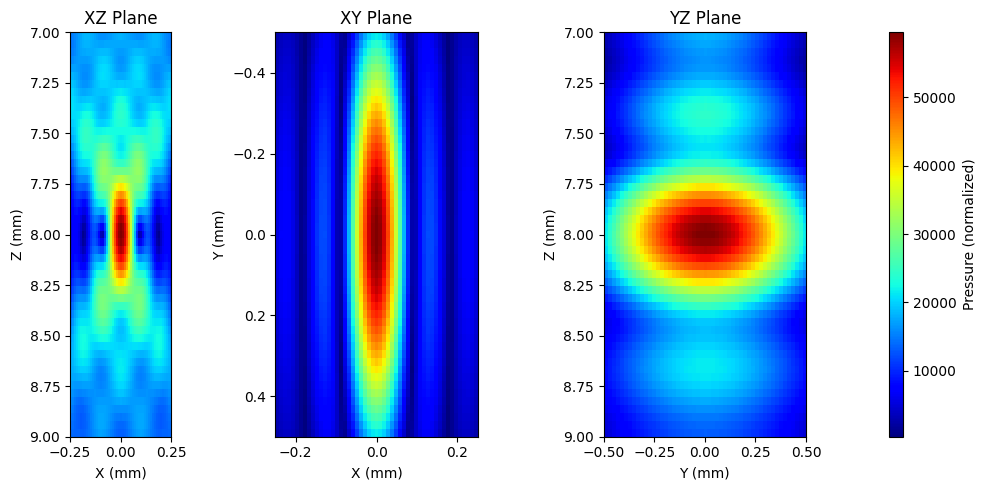

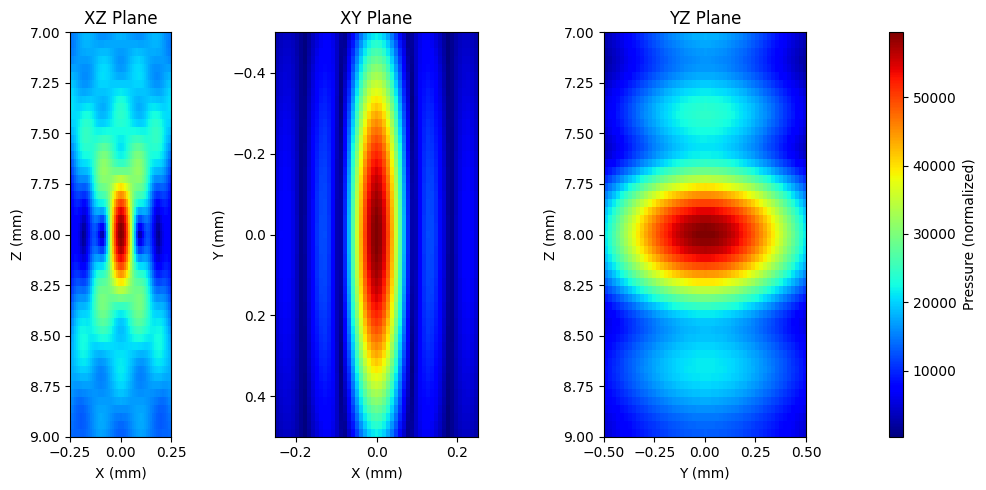

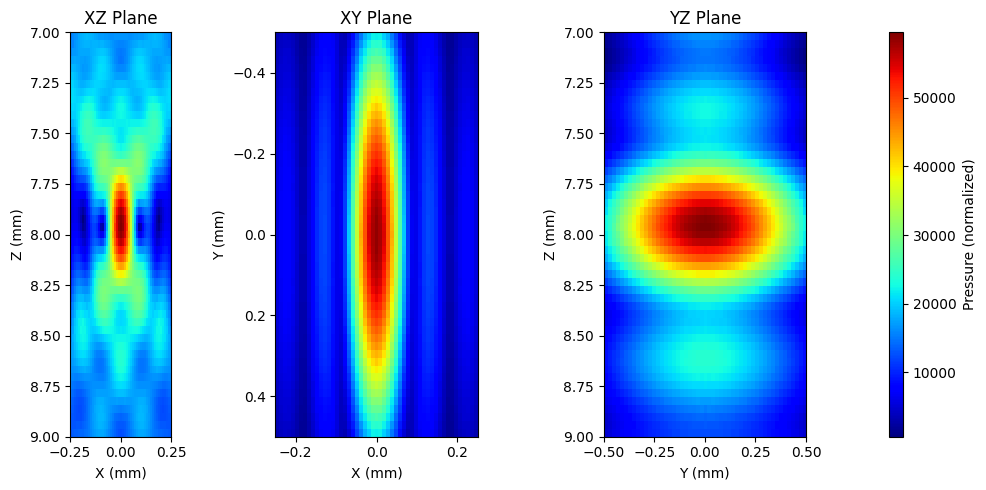

In [29]:
pysonogen.plot_field_planes(p_field1, x1, y1, z1)
pysonogen.plot_field_planes(p_field2, x2, y2, z2)
pysonogen.plot_field_planes(p_field3, x3, y3, z3)

### 2.2.1. Matrix array probe

In [30]:

x_half_size_mm = 0.3
y_half_size_mm = 0.3
z_half_size_mm = 1
x_extent_mm = [-x_half_size_mm+focus_mm[0], x_half_size_mm+focus_mm[0]]
y_extent_mm = [-y_half_size_mm+focus_mm[1], y_half_size_mm+focus_mm[1]]
z_extent_mm = [-z_half_size_mm +focus_mm[2], z_half_size_mm+focus_mm[2]]
dx_mm = 0.03
dy_mm = 0.03
dz_mm = 0.05

x = np.linspace(x_extent_mm[0], x_extent_mm[1], int((x_extent_mm[1]-x_extent_mm[0])/dx_mm)+1)
y = np.linspace(y_extent_mm[0], y_extent_mm[1], int((y_extent_mm[1]-y_extent_mm[0])/dy_mm)+1)
z = np.linspace(z_extent_mm[0], z_extent_mm[1], int((z_extent_mm[1]-z_extent_mm[0])/dz_mm)+1)
field_info_mm = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)
print(f"Number of field points: {field_info_mm.shape[0]}, x.shape: {x.shape}, y.shape: {y.shape}, z.shape: {z.shape}")
print(f"Field points from {field_info_mm.min(axis=0)} mm to {field_info_mm.max(axis=0)} mm")

Number of field points: 18081, x.shape: (21,), y.shape: (21,), z.shape: (41,)
Field points from [-0.3 -0.3  7. ] mm to [0.3 0.3 9. ] mm


MatrixArrayTransducer initialized with 3025 elements and 12100 patches.
Transducer initialized in 0.0771 seconds.


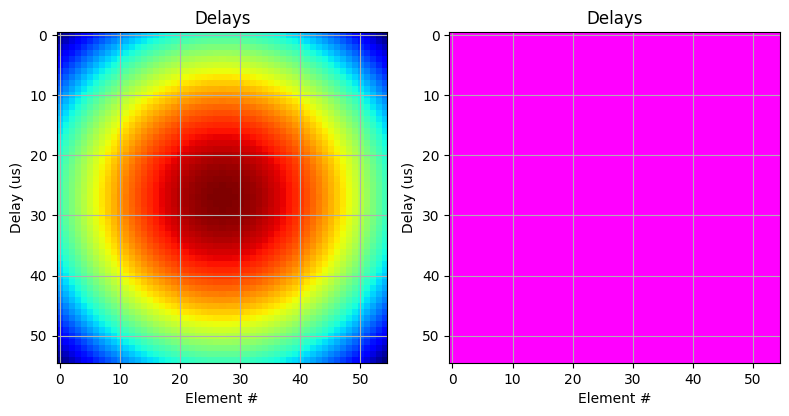

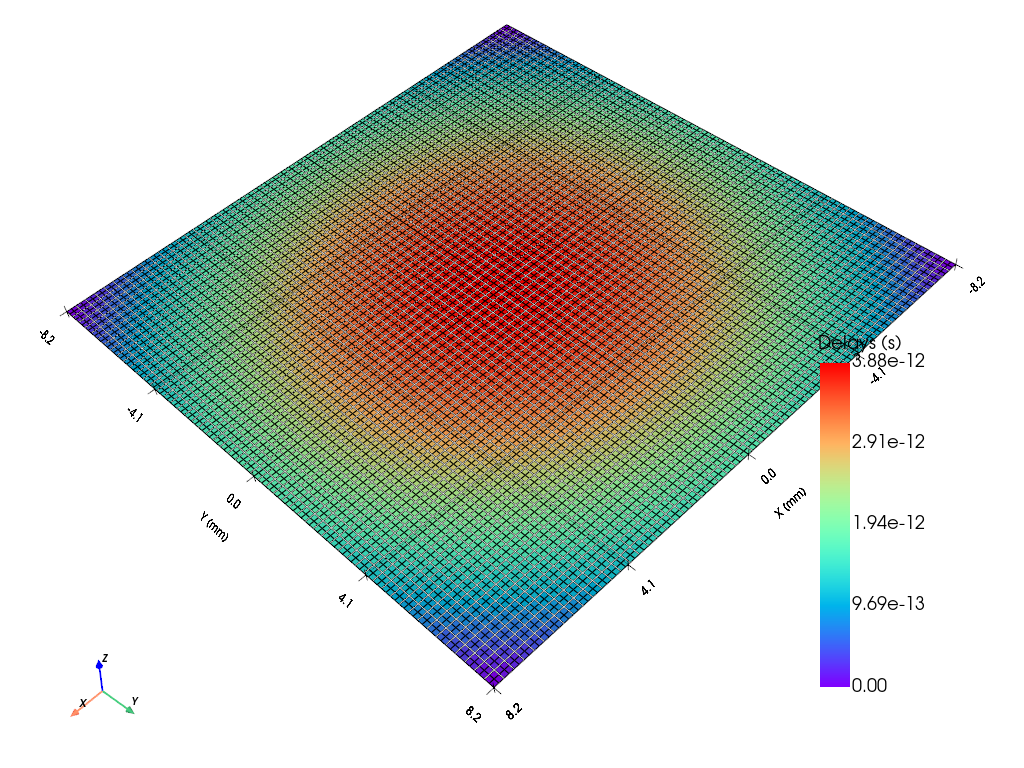

In [31]:
matrix_array_probe = Zeus_Matrix()

delays = matrix_array_probe.compute_delays(focus_mm=focus_mm)
# apodization = matrix_array_probe.compute_apodization( 
#     focus_mm=focus_mm, FoverD=FoverD)
matrix_array_probe.plot_delays_apodization()
matrix_array_probe.show(notebook=True, jupyter_backend='static', scalars = "Delays")


### 2.3.2. Matrix array probe

In [32]:
matrix_field = PyField(matrix_array_probe)
x1, y1, z1, p_field1 = matrix_field(field_info_mm, method = 'naive')

Points checked and spatial grid created in 0.00 seconds...
Computing SIR for 18081 points and 12100 patches...
Computed time grid from 4.45 us to 13.70 us, with 1851 samples in 0.06 seconds.
SIR computed in 1.06 seconds...
Pressure computed from SIR in 0.64 seconds...
Pressure field computed in 2.35 seconds...


In [33]:
x1, y1, z1, p_field1 = matrix_field(field_info_mm, method = 'naive')

Points checked and spatial grid created in 0.00 seconds...
Computing SIR for 18081 points and 12100 patches...
Computed time grid from 4.45 us to 13.70 us, with 1851 samples in 0.05 seconds.
SIR computed in 0.96 seconds...
Pressure computed from SIR in 0.57 seconds...
Pressure field computed in 2.08 seconds...


In [34]:
x2, y2, z2, p_field2 = matrix_field(field_info_mm, method = 'sdi')

Points checked and spatial grid created in 0.00 seconds...
Computing SIR for 18081 points and 12100 patches...


Computed time grid from 4.45 us to 13.70 us, with 1851 samples in 0.09 seconds.
SIR computed in 0.60 seconds...
Pressure computed from SIR in 0.56 seconds...
Pressure field computed in 1.84 seconds...


In [35]:
x3, y3, z3, p_field3 = matrix_field(field_info_mm, method = 'auto')

Points checked and spatial grid created in 0.00 seconds...
Computing SIR for 18081 points and 12100 patches...
Computed time grid from 4.45 us to 13.70 us, with 1851 samples in 0.06 seconds.
SIR computed in 0.52 seconds...
Pressure computed from SIR in 0.54 seconds...
Pressure field computed in 1.65 seconds...


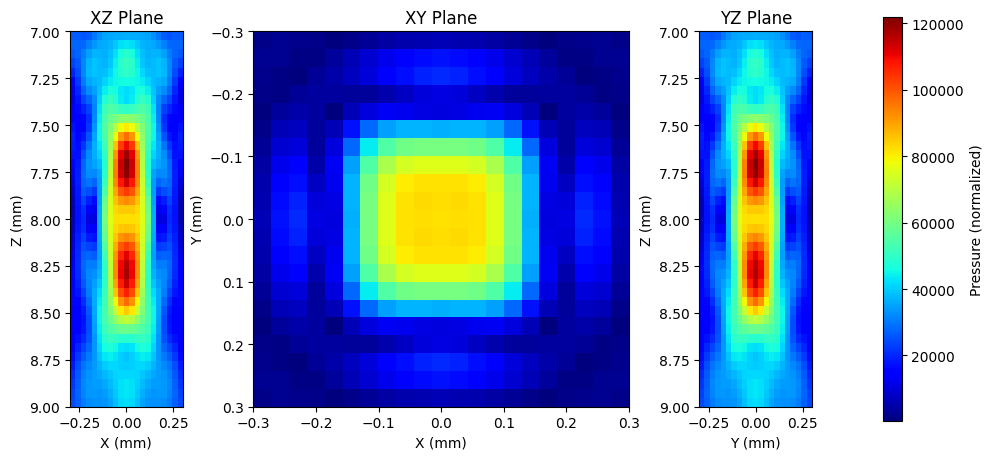

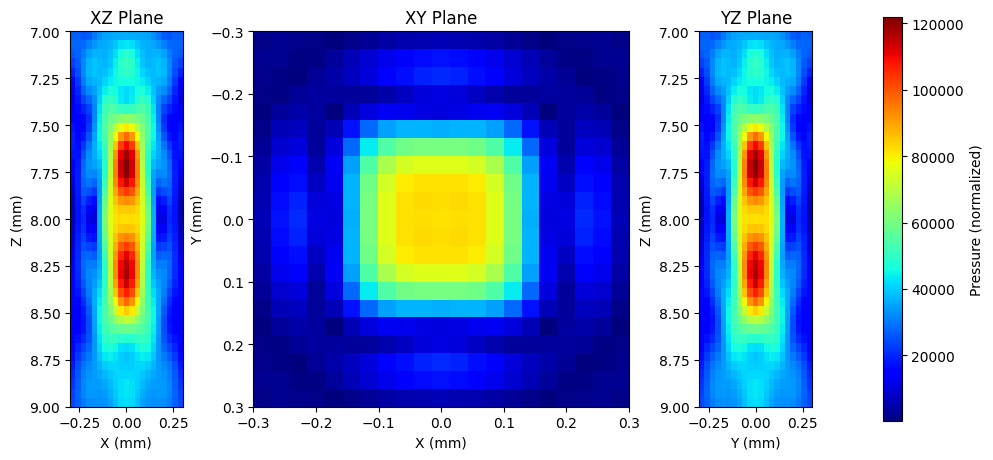

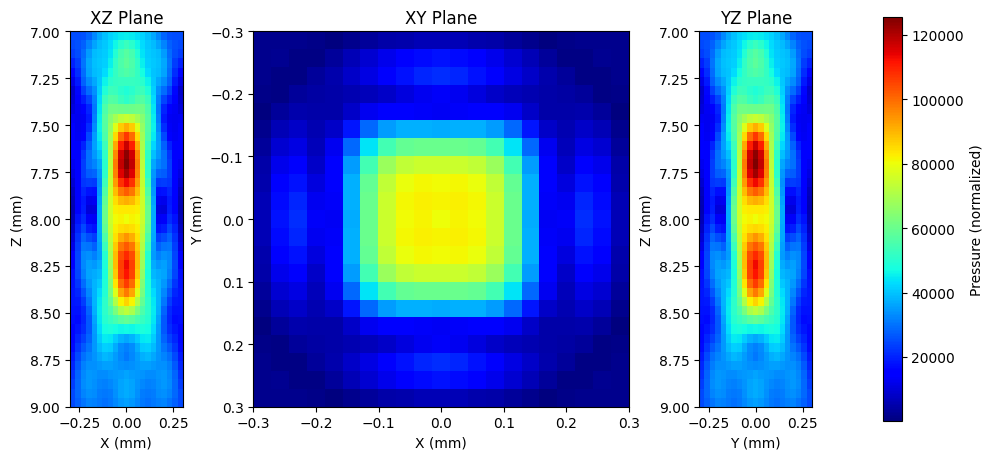

In [36]:
pysonogen.plot_field_planes(p_field1, x1, y1, z1)
pysonogen.plot_field_planes(p_field2, x2, y2, z2)
pysonogen.plot_field_planes(p_field3, x3, y3, z3)

### Comparison results

In [37]:
print(linear_field.sir_running_time_log)
print(matrix_field.sir_running_time_log)

[4.823145151138306, 0.5554747581481934, 0.4554765224456787, 4.579253673553467]
[1.0626342296600342, 0.9580028057098389, 0.5957224369049072, 0.5203478336334229]
